In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and prepare the image
img = cv2.imread('2014Feb.jpg')              # Load your image
# 2. Crop image
img_cropped = img[500:1750, 0:1000]
img_rgb = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
hsv = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

In [2]:
img.max()

255

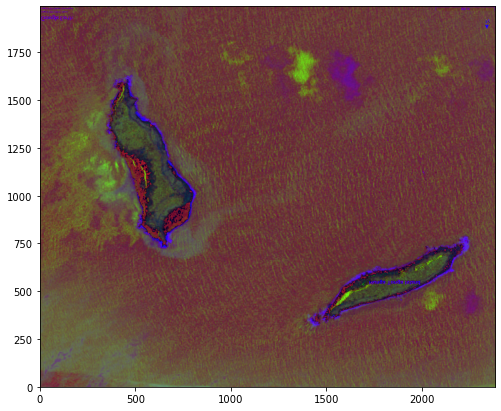

In [3]:
img_rgb_full = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
hsv_full = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(hsv_full, origin="lower")

In [4]:
%matplotlib notebook

<IPython.core.display.Javascript object>


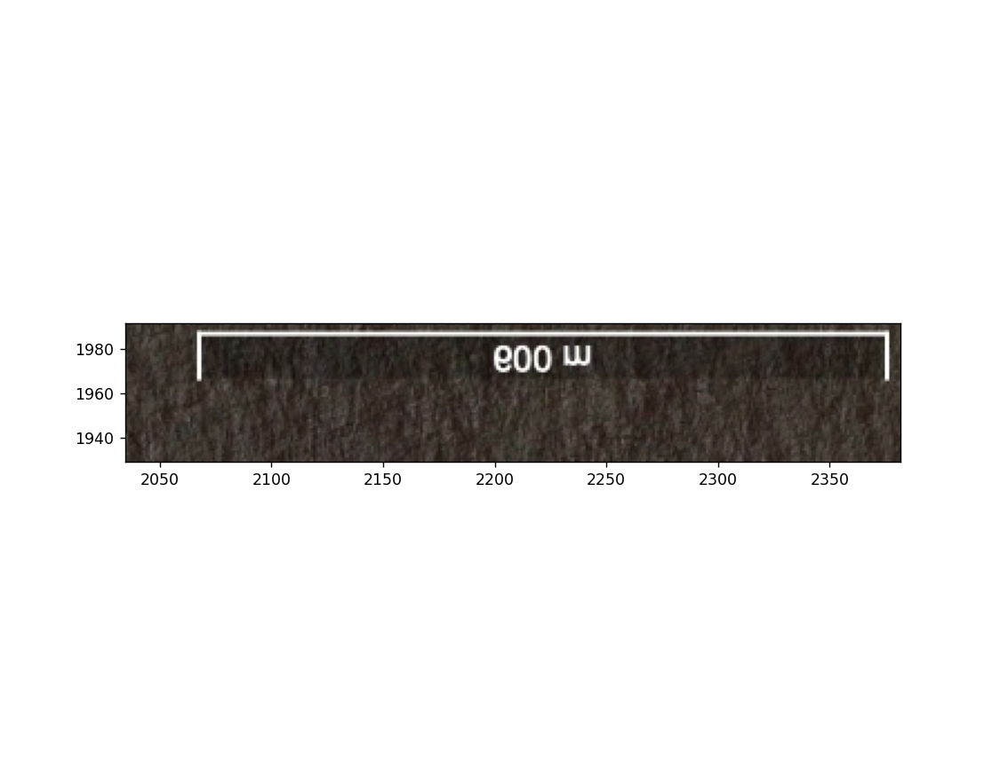

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(img, origin="lower")

<IPython.core.display.Javascript object>


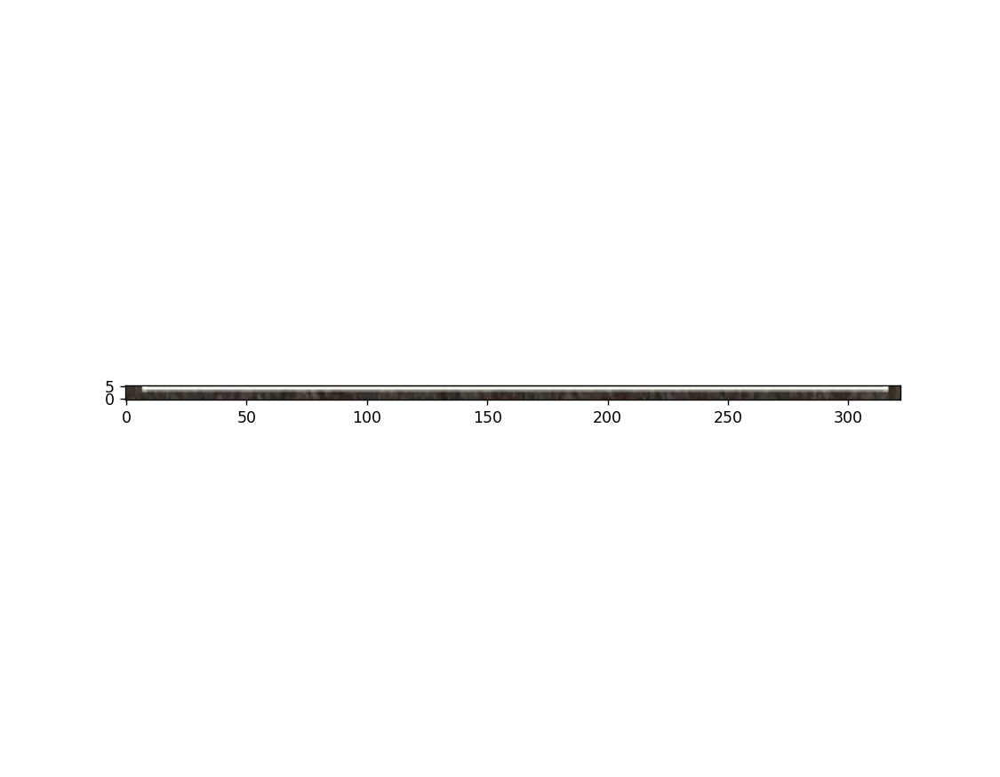

In [11]:
scalebar = img[1986:, 2060:]
scalebar_flipped = cv2.flip(scalebar, 0)
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(scalebar_flipped, origin="lower")

<IPython.core.display.Javascript object>


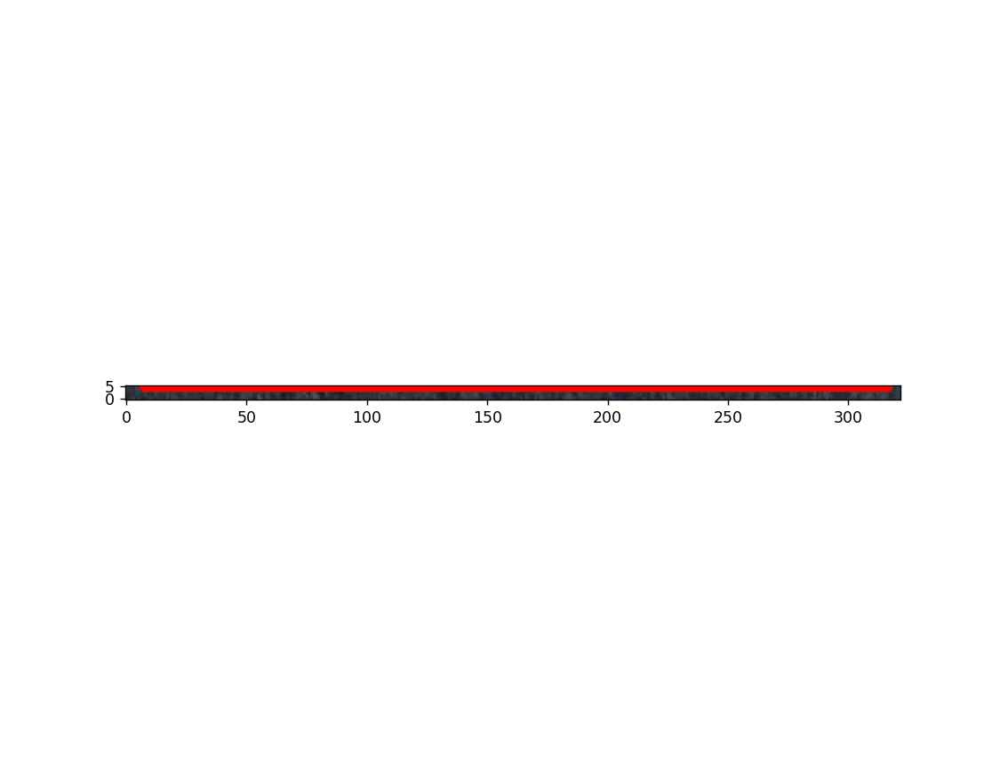

Scale bar pixel length: 310


In [12]:
# Convert to grayscale
gray = cv2.cvtColor(scalebar_flipped, cv2.COLOR_BGR2GRAY)

# Threshold to isolate white scale bar
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get bounding box of the largest white region (likely the scale bar)
max_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(max_contour)

# Show result
cv2.rectangle(scalebar_flipped, (x, y), (x+w, y+h), (0, 0, 255), 2)
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(cv2.cvtColor(scalebar_flipped, cv2.COLOR_BGR2RGB), origin="lower")
#plt.title(f"Scale bar length: {w} pixels")
#plt.show()

print(f"Scale bar pixel length: {w}")

In [13]:
distance_per_pixel = 600 / 310
print(distance_per_pixel)

1.935483870967742


<IPython.core.display.Javascript object>


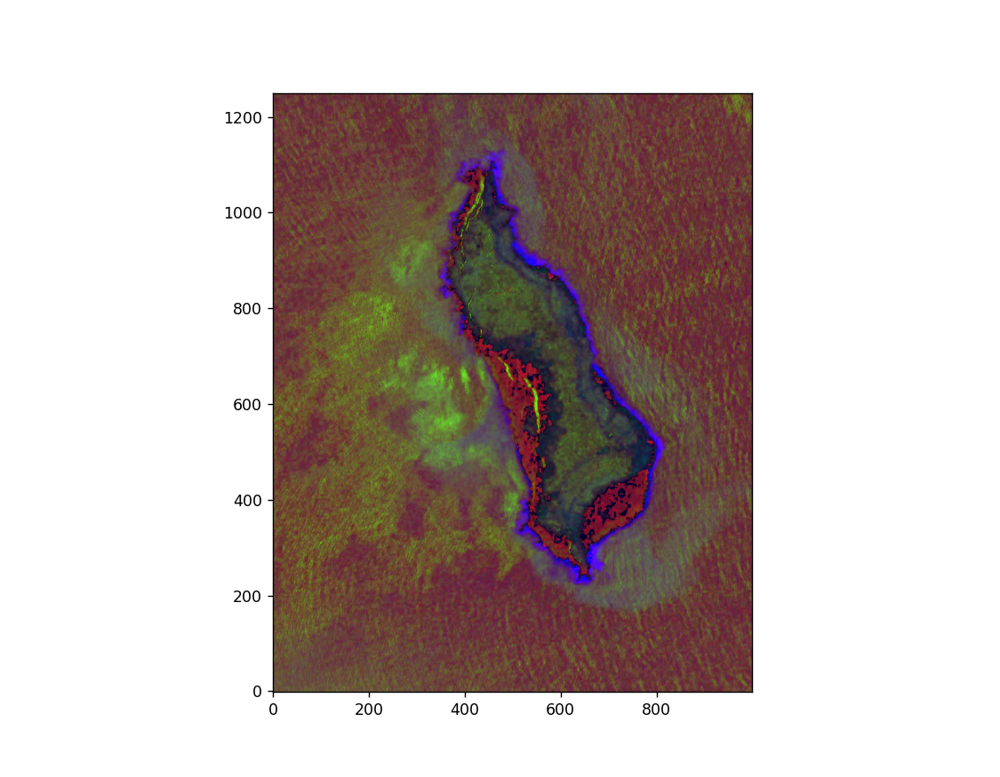

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(hsv, origin="lower")

In [16]:
# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([2, 2, 2])  # Minimum HSV range
upper = np.array([85, 85, 85])  # Maximum HSV range
mask0 = cv2.inRange(hsv, lower, upper)     # Initial binary mask

# 3️. Morphological operations to remove noise and fill gaps
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
mask = cv2.morphologyEx(mask0, cv2.MORPH_CLOSE, kernel, iterations=2)
mask = cv2.morphologyEx(mask,  cv2.MORPH_OPEN,  kernel, iterations=2)

# 4️. Extract contours to isolate the object
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    # Choose the largest contour—typically the target object
    c = max(contours, key=cv2.contourArea)
    can_mask = np.zeros_like(mask)
    cv2.drawContours(can_mask, [c], -1, 255, -1)
else:
    can_mask = mask

# 5️. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(img_rgb, img_rgb, mask=can_mask)

In [17]:
can_mask.max()

255

<IPython.core.display.Javascript object>


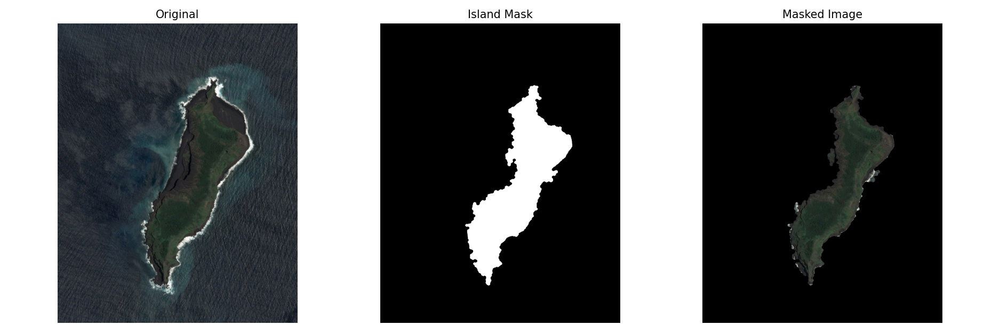

In [18]:
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(img_rgb);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(can_mask, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

sum pixels where mask is true
mask = true for 255

In [22]:
pixel_area = np.sum(can_mask == 255)
print(pixel_area)

133753


In [23]:
area = pixel_area * distance_per_pixel**2
print(area)

501051.8210197711


In [24]:
# 1. Load and prepare the image
#img = cv2.imread('2014Feb.jpg')              # Load your image
# 2. Crop image
island2 = img[250:800, 1300:2280]
img_rgb_2 = cv2.cvtColor(island2, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
hsv2 = cv2.cvtColor(island2, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

In [34]:
# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([2, 2, 2])  # Minimum HSV range
upper = np.array([80, 80, 80])  # Maximum HSV range
mask1 = cv2.inRange(hsv2, lower, upper)     # Initial binary mask

# 3️. Morphological operations to remove noise and fill gaps
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
mask0 = cv2.morphologyEx(mask1, cv2.MORPH_CLOSE, kernel, iterations=2)
mask2 = cv2.morphologyEx(mask0,  cv2.MORPH_OPEN,  kernel, iterations=2)

# 4️. Extract contours to isolate the object
contours, _ = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    # Choose the largest contour—typically the target object
    c = max(contours, key=cv2.contourArea)
    can_mask = np.zeros_like(mask2)
    cv2.drawContours(can_mask, [c], -1, 255, -1)
else:
    can_mask = mask2

# 5️. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(img_rgb_2, img_rgb_2, mask=can_mask)

<IPython.core.display.Javascript object>


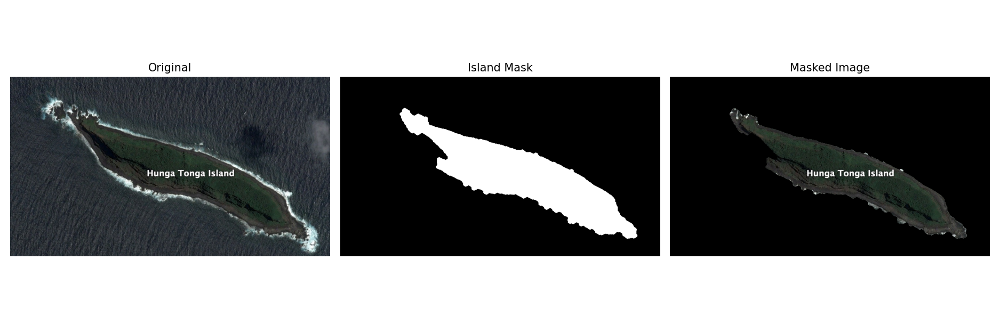

In [35]:
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(img_rgb_2);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(can_mask, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

In [28]:
pixel_area_2 = np.sum(can_mask == 255)
print(pixel_area_2)

88409


In [30]:
area_2 = pixel_area_2 * distance_per_pixel**2
print(area_2)

331188.7617065557


In [31]:
total_area = area + area_2
print(total_area)

832240.5827263268


In [38]:
# 1. Load and prepare the image
may = cv2.imread('2016May.jpg')              # Load your image
# 2. Crop image
may_rgb = cv2.cvtColor(may, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
may_hsv = cv2.cvtColor(may, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

<IPython.core.display.Javascript object>


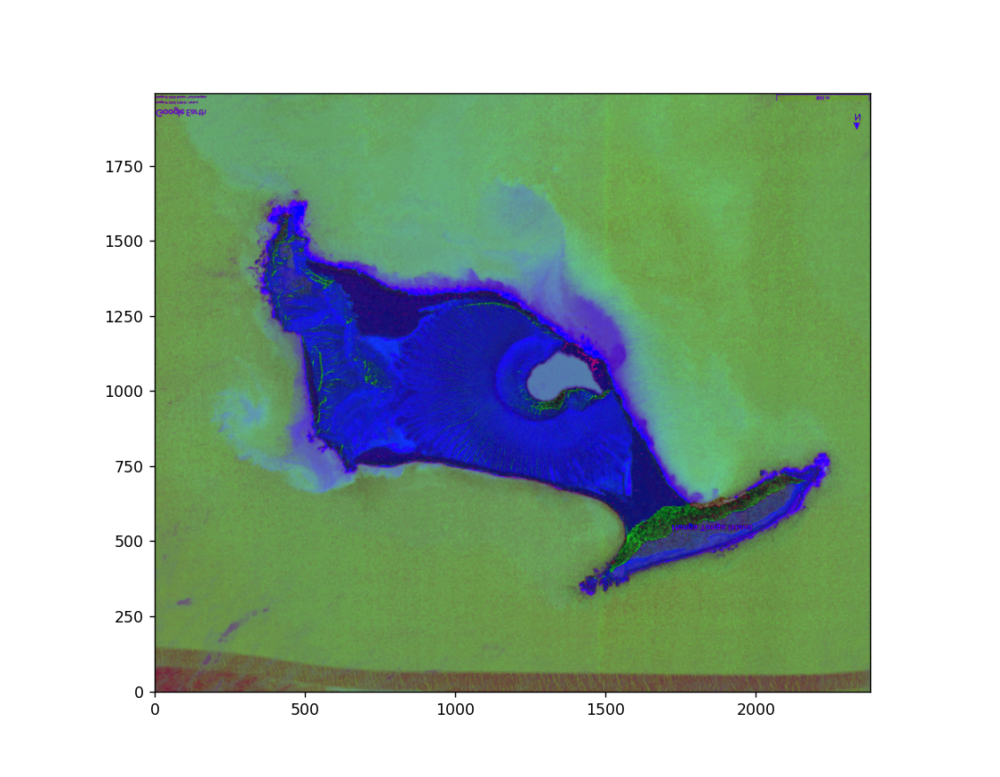

In [37]:
may_rgb_full = cv2.cvtColor(may, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
may_hsv_full = cv2.cvtColor(may, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(may_hsv_full, origin="lower")

In [80]:
# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([80, 1, 1])  # Minimum HSV range
upper = np.array([200, 255, 255])  # Maximum HSV range
mask_may = cv2.inRange(may_hsv, lower, upper)     # Initial binary mask

# 3️. Morphological operations to remove noise and fill gaps
#kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
#mask_may1 = cv2.morphologyEx(mask_may0, cv2.MORPH_CLOSE, kernel, iterations=2)
#mask_may = cv2.morphologyEx(mask_may1,  cv2.MORPH_OPEN,  kernel, iterations=2)

# 4️. Extract contours to isolate the object
#contours, _ = cv2.findContours(mask_may, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#if contours:
    # Choose the largest contour—typically the target object
 #   c = max(contours, key=cv2.contourArea)
  #  can_mask = np.zeros_like(mask_may)
   # cv2.drawContours(can_mask, [c], -1, 255, -1)
#else:
 #   can_mask = mask_may

# 3. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(may_rgb, may_rgb, mask=mask_may)

<IPython.core.display.Javascript object>


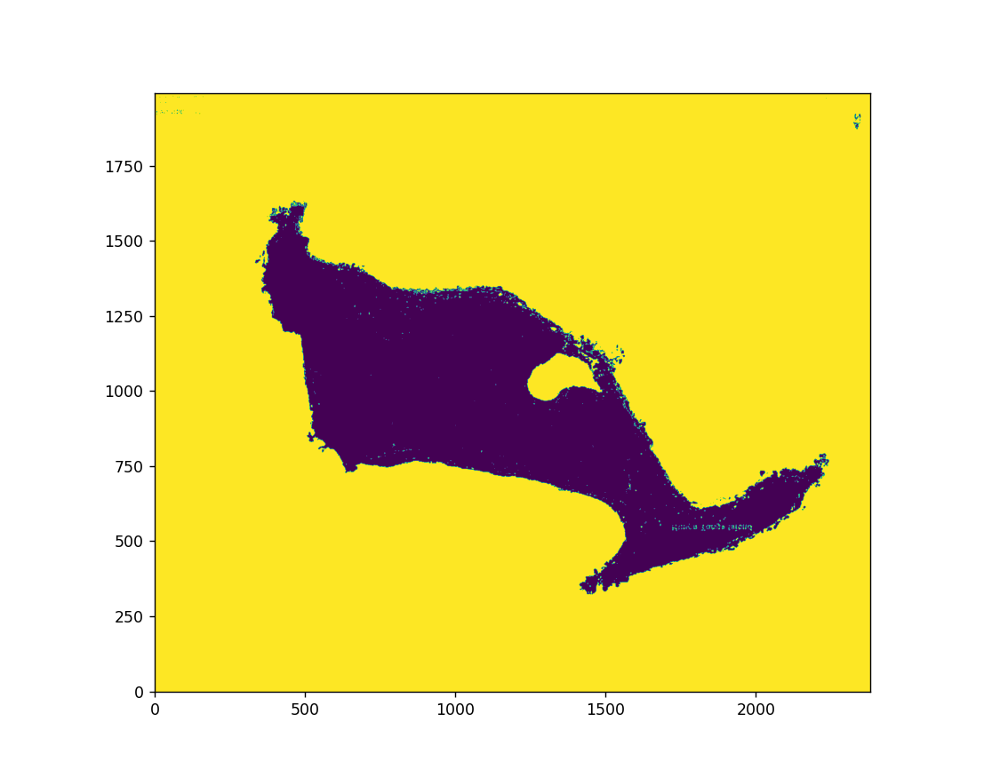

In [81]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(mask_may, origin="lower")

In [68]:
mask_may.max()

255

In [69]:
pixel_area_may = np.sum(mask_may == 0)
print(pixel_area_may)

788093


In [70]:
area_may = pixel_area_may * distance_per_pixel**2
print(area_may)

2952273.465140479


<IPython.core.display.Javascript object>


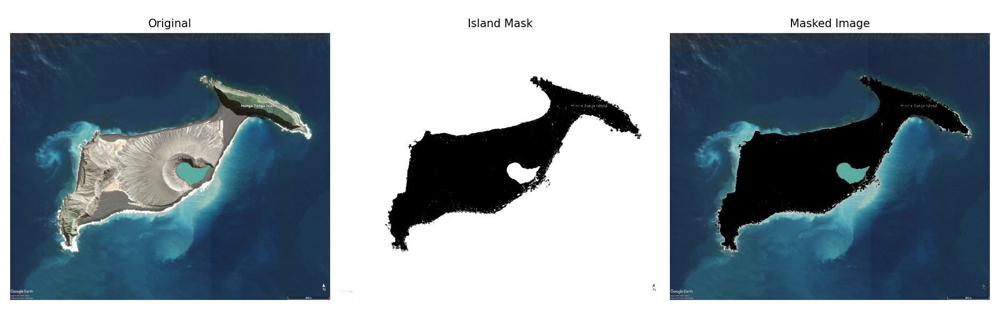

In [79]:
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(may_rgb);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(mask_may, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

<IPython.core.display.Javascript object>


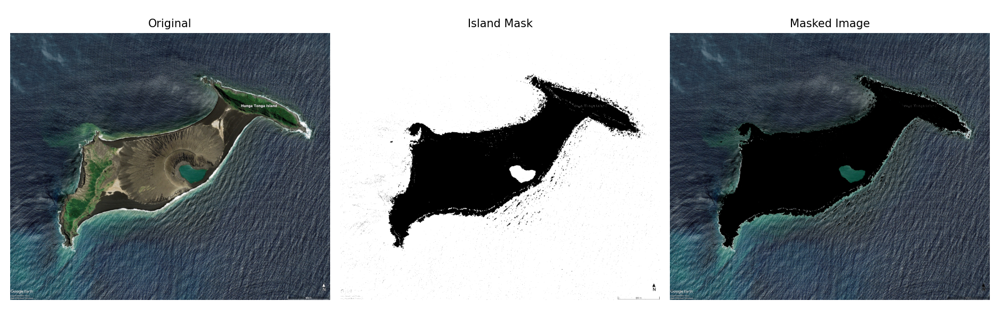

3171157.9604578568


In [85]:
# 1. Load and prepare the image
nov = cv2.imread('2020Nov.jpg')              # Load your image
# 2. Crop image
nov_rgb = cv2.cvtColor(nov, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
nov_hsv = cv2.cvtColor(nov, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([80, 1, 1])  # Minimum HSV range
upper = np.array([200, 250, 250])  # Maximum HSV range
mask_nov = cv2.inRange(nov_hsv, lower, upper)     # Initial binary mask

# 3. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(nov_rgb, nov_rgb, mask=mask_nov)

fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(nov_rgb);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(mask_nov, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

# 4. Calculate the area
pixel_area_nov = np.sum(mask_nov == 0)
area = pixel_area_nov * distance_per_pixel**2
print(area)

<IPython.core.display.Javascript object>


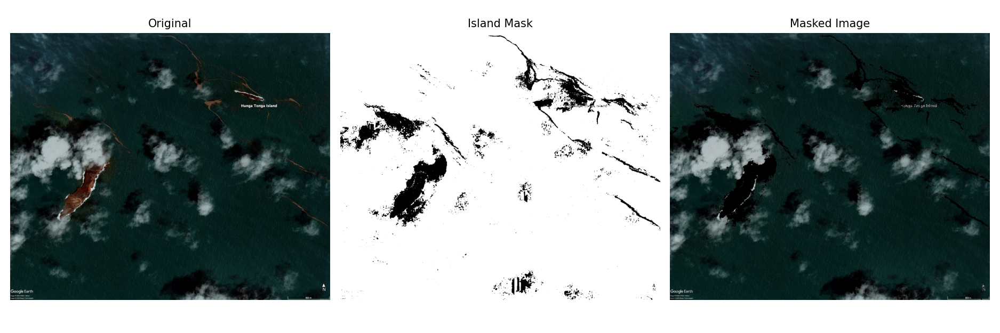

1129508.4287200833


In [91]:
# 1. Load and prepare the image
jan = cv2.imread('2022Jan.jpg')              # Load your image
# 2. Crop image
jan_rgb = cv2.cvtColor(jan, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
jan_hsv = cv2.cvtColor(jan, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([80, 1, 1])  # Minimum HSV range
upper = np.array([255, 255, 255])  # Maximum HSV range
mask_jan = cv2.inRange(jan_hsv, lower, upper)     # Initial binary mask

# 3. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(jan_rgb, jan_rgb, mask=mask_jan)

fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(jan_rgb);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(mask_jan, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

# 4. Calculate the area
pixel_area_jan = np.sum(mask_jan == 0)
area = pixel_area_jan * distance_per_pixel**2
print(area)

<IPython.core.display.Javascript object>


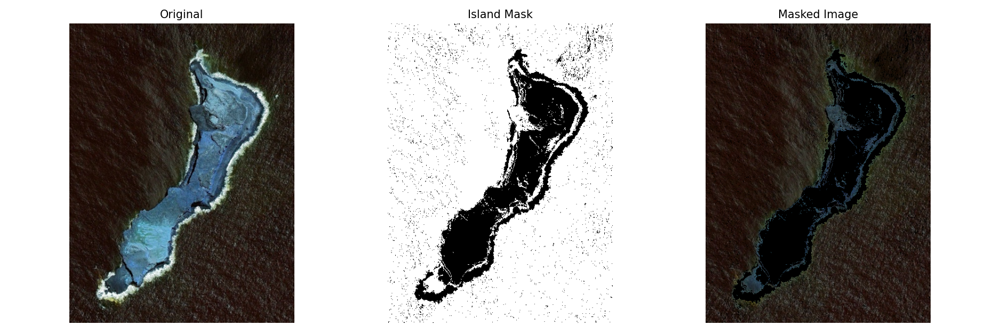

830322.5806451613


In [115]:
# 1. Load and prepare the image
octob = cv2.imread('2023Oct.jpg')              # Load your image
octob_cropped = octob[830:1430, 300:750]
# 2. Crop image
octob_rgb = cv2.cvtColor(octob_cropped, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
octob_hsv = cv2.cvtColor(octob_cropped, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([20, 1, 1])  # Minimum HSV range
upper = np.array([140, 100, 100])  # Maximum HSV range
mask_octob = cv2.inRange(octob_cropped, lower, upper)     # Initial binary mask

# 3. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(octob_cropped, octob_cropped, mask=mask_octob)

fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(octob_cropped);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(mask_octob, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

# 4. Calculate the area
pixel_area_octob = np.sum(mask_octob == 255)
area = pixel_area_octob * distance_per_pixel**2
print(area)

<IPython.core.display.Javascript object>


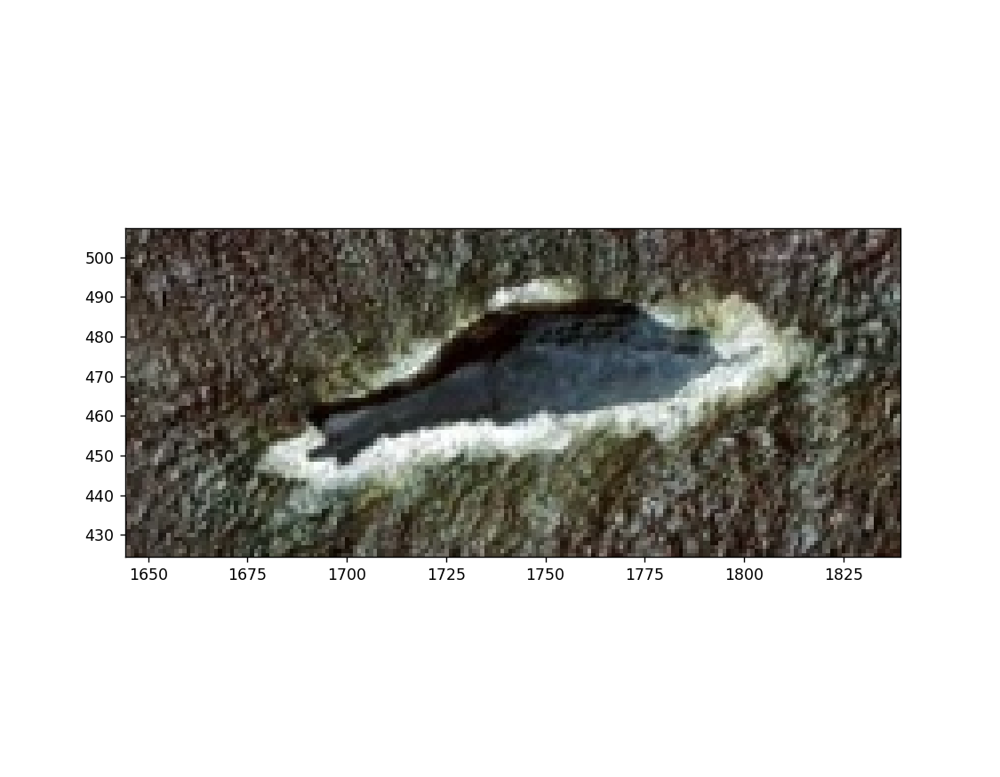

In [116]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(octob, origin="lower")

<IPython.core.display.Javascript object>


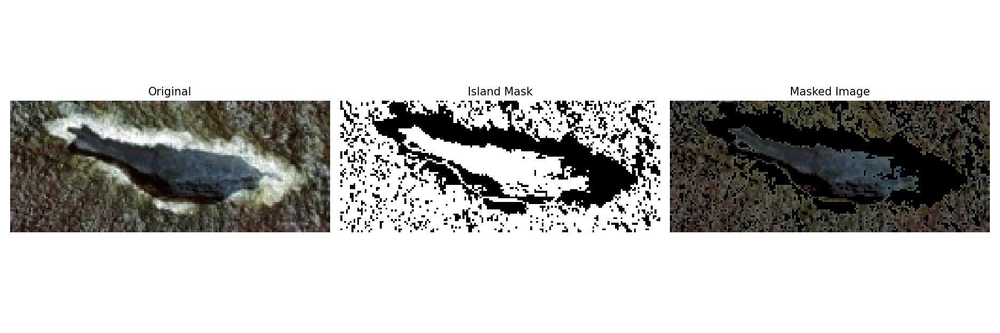

28024.557752341316


In [120]:
# 1. Load and prepare the image
#octob = cv2.imread('2023Oct.jpg')              # Load your image
octob_cropped2 = octob[435:505, 1660:1830]
# 2. Crop image
octob_rgb2 = cv2.cvtColor(octob_cropped2, cv2.COLOR_BGR2RGB)   # Convert to RGB for display
octob_hsv2 = cv2.cvtColor(octob_cropped2, cv2.COLOR_BGR2HSV)   # Convert to HSV for color filtering

# 2️. Define HSV thresholds for target object (yellow-green can)
lower = np.array([20, 20, 20])  # Minimum HSV range
upper = np.array([100, 100, 100])  # Maximum HSV range
mask_octob2 = cv2.inRange(octob_cropped2, lower, upper)     # Initial binary mask

# 3. Apply the refined mask to the RGB image
def_mask = cv2.bitwise_and(octob_cropped2, octob_cropped2, mask=mask_octob2)

fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(octob_cropped2);      axs[0].set_title('Original');    axs[0].axis('off')
axs[1].imshow(mask_octob2, cmap='gray'); axs[1].set_title('Island Mask'); axs[1].axis('off')
axs[2].imshow(def_mask);     axs[2].set_title('Masked Image'); axs[2].axis('off')
plt.tight_layout(); plt.show()

# 4. Calculate the area
pixel_area_octob2 = np.sum(mask_octob2 == 255)
area2 = pixel_area_octob2 * distance_per_pixel**2
print(area2)